In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
import torchvision.transforms as T


**Load one image and check info**

In [42]:
img_path = "Shapes/line-long-vert-mid.png"

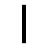

In [43]:
# Open image and convert to grayscale
image = Image.open(img_path).convert("L")
image

In [57]:
image.size

(48, 48)

In [45]:
image, type(image)

(<PIL.Image.Image image mode=L size=48x48>, PIL.Image.Image)

(np.float64(-0.5), np.float64(47.5), np.float64(47.5), np.float64(-0.5))

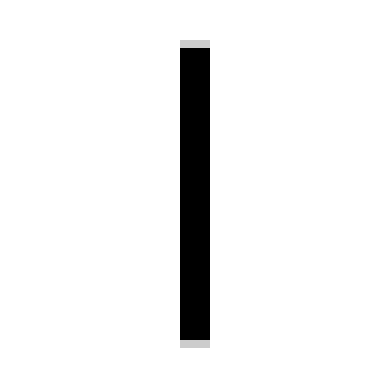

In [46]:
plt.imshow(image, cmap="gray")
plt.axis("off")
# plt.figure(figsize=(2, 2))  # Increase this to make it bigger

In [48]:
# Transform to tensor (range: 0 to 1)
transform = T.ToTensor()
image_tensor = transform(image)  # shape: (1, H, W)
# print(image_tensor.ndim)
# Add batch dimension -> (B, C, H, W)
image_tensor = image_tensor.unsqueeze(0)
image_tensor.shape

torch.Size([1, 1, 48, 48])

**Define a Kernel**

Image is ready, so now define a kernel manually:

In [52]:
kernel = torch.tensor([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=torch.float32)
kernel.shape

torch.Size([3, 3])

In [53]:
# Reshape kernel -> (out_channels, in_channels, kH, kW)
kernel = kernel.unsqueeze(0).unsqueeze(0)
kernel.shape

torch.Size([1, 1, 3, 3])

In [56]:
kernel.shape[-2:]

torch.Size([3, 3])

In [24]:
kernel

tensor([[[[ 0., -1.,  0.],
          [-1.,  5., -1.],
          [ 0., -1.,  0.]]]])

**Applying Convolution**

In [31]:
output = F.conv2d(image_tensor, kernel)  #, padding=1)
# Remove batch and channel dims for visualization
output_image_tensor = output.squeeze()
output.shape, output_image_tensor.shape

(torch.Size([1, 1, 46, 46]), torch.Size([46, 46]))

**Print Details**

In [33]:
print("Input Shape  :", image_tensor.shape)
print("Kernel Shape :", kernel.shape)
print("Output Shape :", output.shape)
print("Output Tensor Shape :", output_image_tensor.shape)

print("\nKernel:\n", kernel)

Input Shape  : torch.Size([1, 1, 48, 48])
Kernel Shape : torch.Size([1, 1, 3, 3])
Output Shape : torch.Size([1, 1, 46, 46])
Output Tensor Shape : torch.Size([46, 46])

Kernel:
 tensor([[[[ 0., -1.,  0.],
          [-1.,  5., -1.],
          [ 0., -1.,  0.]]]])


**Plot Input VS Output**

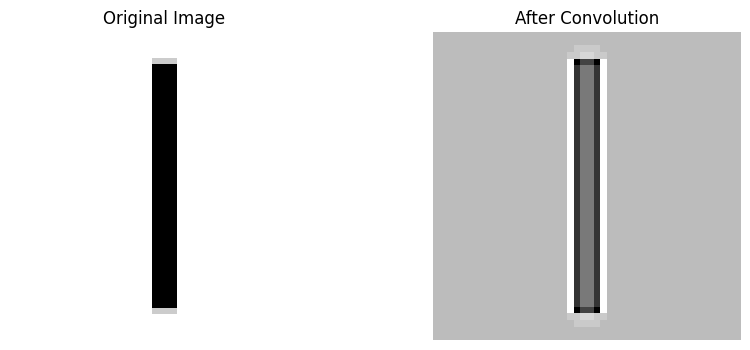

In [34]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("After Convolution")
plt.imshow(output_image.detach().numpy(), cmap='gray')
plt.axis('off')

plt.show()

**Modular implementation for multiple experiments**

In [40]:
from typing import List, Optional

In [58]:
class ImageReader:
    def __init__(self, image_path: str):
        self._image_path = image_path
        self._image = None
        self.image_tensor = None
    def read_image(self):
        self._image = Image.open(img_path).convert("L")
        print(f"Image loaded; shape: {image.size}")
    def to_tensor(self):
        transform = T.ToTensor()
        image_tensor = transform(self._image)  # shape: (1, H, W)
        if image_tensor.ndim==3:
            # Add batch dimension -> (B, C, H, W)
            self.image_tensor = image_tensor.unsqueeze(0)
        elif image_tensor.ndim==2:
            # Add batch and channel dimension -> (B, C, H, W)
            self.image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)
        else:
            # Shape mismatch
            raise ValueError("Something is wrong in the image: shape mismatch")
        print(f"Image tensor shape: {self.image_tensor.shape}")
    def plot_image(self):
        plt.imshow(self._image, cmap="gray")
        plt.axis("off")
        plt.figure(figsize=(2, 2))
    def get_size(self) -> tuple:
        if self._image:
            return tuple(self._image.size())
        else:
            raise RuntimeError("The 'read_image()' method must be called before and get the image loaded.")
# image_1, image_2, ...

In [59]:
class KernelMaker:
    def __init__(self, kernels: list):
        self._kernels = kernels
        self.kernel_tensors = []
    def set_kernels(self):
        for kernel in self._kernels:
            t = torch.tensor(kernel)  # assuming 2d tensor
            if t.ndim != 2:
                raise ValueError(f"One or more tensor(s) with dimention {t.ndim}. But currently only tensor(s) with dim 2 is (are) accepted.")
            t = t.unsqueeze(0).unsqueeze(0)
            self.kernel_tensors.append(t)
        print(f"{self.kernels_count} kernels set to tensors for further operation")
    def kernels_count(self):
        return len(self._kernels)
    def print_kernels_info(self, print_all: Optional[bool] = False):
        print(f"Total {self.kernels_count} kernel(s) is(are) available")
        if self.kernels_count==len(self.kernel_tensors):
            print("All kernels are already set to tensors. Ready to do further operations.")
            if (not print_all):
                print("Details of first kernel:")
                print(f"Shape of the kernel tensor at index 0: {self.kernel_tensors[0].shape}")
                print(f"The kernel tensor looks like the following:\n{self.kernel_tensors[0]}")
            else:
                print("Details of first kernel:")
                for idx, kernel_tensor in enumerate(self.kernel_tensors):
                    print(f"Shape of the kernel tensor at index {idx}: {self.kernel_tensors[idx].shape}")
                    print(f"The kernel tensor looks like the following:\n{self.kernel_tensors[idx]}\n")
        else:
            print("Kernels are not set to tensors. Set kernels to tensors for further operations.")
    def get_size(self, idx: int) -> tuple:
        if self.kernel_tensors:
            kernel_shape = self.kernel_tensors[idx].shape
            return tuple(kernel_shape[-2:])
        else:
            raise RuntimeError("The 'set_kernels()' method must be called before and get the kernels set.")
# kernels, kernel_set1, kernel_set2, ...

In [62]:
class OpsVisualizer:
    def __init__(self, image: torch.Tensor, kernels: List[torch.Tensor]):
        self.image_tensor = image
        self.kernel_tensors = kernels
        self.output_image_tensors = []
    def op_conv2d(self, padding: int = 0, stride: int = 1, full_viz: bool = False, idx: bool = None):
        print(f"Convolving image of size: {self.image_tensor.shape} with ...")  # tuple(self.image_tensor.shape[-2:])
        # if id
        for idx, kernel_tensor in enumerate(self.kernel_tensors):
            print(f"Kernel index: {idx}\n{self.kernels.kernel_tensors[idx]}")
            output = F.conv2d(self.image_tensor, kernel_tensor)  #, padding=1)
            # Remove batch and channel dims for visualization
            self.output_image_tensors.append(output)
            # print kernel, print image, print out image plt
            plot_3(self.image, kernel_tensor, output)
    def plot_3(image_t, kernel, out_image_t):
        if image_t.ndim==4:
            image_t = image_t.squeeze()
        if kernel.ndim==4:
            kernel = kernel.squeeze()
        if out_image_t.ndim==4:
            out_image_t = out_image_t.squeeze()
        fig, axes = plt.subplots(1, 3, figsize=(10, 4))
        # --- Original image ---
        axes[0].imshow(image_t, cmap='gray')
        axes[0].axis('off')
        axes[0].set_title("Original Image")
        # --- Matrix (as LaTeX text) ---
        k = kernel.detach().cpu().numpy()
        axes[1].axis('off')
        axes[1].table(cellText=k, loc='center')
        axes[1].set_title("Kernel")
        # --- Output image ---
        axes[2].imshow(out_image_t, cmap='gray')
        axes[2].axis('off')
        axes[2].set_title("Output image")
        plt.tight_layout()
        plt.show()

In [63]:
ir = ImageReader("Shapes/line-long-vert-mid.png")
ir.read_image()
ir.to_tensor()
klist = [
    [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
    # 
]
km = KernelMaker(klist)
km.set_kernels()
km.print_kernels_info(print_all=True)


Image loaded; shape: (48, 48)
Image tensor shape: torch.Size([1, 1, 48, 48])
<bound method KernelMaker.kernels_count of <__main__.KernelMaker object at 0x70a4afcc4040>> kernels set to tensors for further operation
Total <bound method KernelMaker.kernels_count of <__main__.KernelMaker object at 0x70a4afcc4040>> kernel(s) is(are) available
Kernels are not set to tensors. Set kernels to tensors for further operations.


In [67]:
len(km._kernels)

1

In [ ]:
viz = OpsVisualizer(ir.image_tensor, km.kernel_tensors)
viz.op_conv2d()